Jupyter Notebook for the Kaggle Competition (Machine Learning - CentraleSupélec - January 2025)  
PAES DE ALMEIDA NINA DUARTE, Pedro ; COLLIER, Grégoire ; PERARDT MAGALHÃES BRITO, Romero

Import necessary packages

In [1]:
import geopandas as gpd
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

Import data (as shown in the baseline code) and treat NaN

In [2]:
change_type_map = {'Demolition': 0, 'Road': 1, 'Residential': 2, 'Commercial': 3, 'Industrial': 4,
                   'Mega Projects': 5}

## Read csvs

train_df = gpd.read_file('train.geojson', index_col=0)
test_df = gpd.read_file('test.geojson', index_col=0)

train_y = train_df['change_type'].apply(lambda x: change_type_map[x])

c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(
c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(


In [6]:
features = train_df.columns.to_list()
features = [feature for feature in features if feature != 'change_type']
features

['urban_type',
 'geography_type',
 'img_red_mean_date1',
 'img_green_mean_date1',
 'img_blue_mean_date1',
 'img_red_std_date1',
 'img_green_std_date1',
 'img_blue_std_date1',
 'img_red_mean_date2',
 'img_green_mean_date2',
 'img_blue_mean_date2',
 'img_red_std_date2',
 'img_green_std_date2',
 'img_blue_std_date2',
 'img_red_mean_date3',
 'img_green_mean_date3',
 'img_blue_mean_date3',
 'img_red_std_date3',
 'img_green_std_date3',
 'img_blue_std_date3',
 'img_red_mean_date4',
 'img_green_mean_date4',
 'img_blue_mean_date4',
 'img_red_std_date4',
 'img_green_std_date4',
 'img_blue_std_date4',
 'img_red_mean_date5',
 'img_green_mean_date5',
 'img_blue_mean_date5',
 'img_red_std_date5',
 'img_green_std_date5',
 'img_blue_std_date5',
 'date0',
 'change_status_date0',
 'date1',
 'change_status_date1',
 'date2',
 'change_status_date2',
 'date3',
 'change_status_date3',
 'date4',
 'change_status_date4',
 'index',
 'geometry']

In [7]:
train_df.shape

(296146, 45)

In [8]:
train_df

,urban_type,geography_type,change_type,img_red_mean_date1,img_green_mean_date1,img_blue_mean_date1,img_red_std_date1,img_green_std_date1,img_blue_std_date1,img_red_mean_date2,...,date1,change_status_date1,date2,change_status_date2,date3,change_status_date3,date4,change_status_date4,index,geometry
0,Sparse Urban,"Dense Forest,Grass Land",Road,93.371775,107.291113,89.827379,29.812040,28.328368,25.324294,125.773062,...,09-12-2013,Greenland,10-09-2016,Construction Started,22-07-2019,Construction Done,24-07-2017,Construction Midway,0,"POLYGON ((112.16774 32.02198, 112.16845 32.020..."
1,Sparse Urban,"Dense Forest,Grass Land",Road,96.071674,107.061702,90.755556,24.896240,22.275180,22.080686,133.097679,...,09-12-2013,Greenland,10-09-2016,Land Cleared,22-07-2019,Construction Done,24-07-2017,Construction Midway,1,"POLYGON ((112.16849 32.02048, 112.16891 32.019..."
2,Sparse Urban,"Dense Forest,Grass Land",Road,101.212148,113.462178,95.670574,24.179684,21.873401,21.285197,120.713490,...,09-12-2013,Greenland,10-09-2016,Land Cleared,22-07-2019,Construction Done,24-07-2017,Land Cleared,2,"POLYGON ((112.16892 32.01969, 112.16962 32.018..."
3,Rural,"Dense Forest,Grass Land",Road,94.463311,99.995531,84.470046,26.869852,23.767679,19.351983,114.819776,...,09-12-2013,Greenland,10-09-2016,Construction Started,22-07-2019,Construction Done,24-07-2017,Construction Midway,3,"POLYGON ((112.16966 32.0181, 112.17033 32.0166..."
4,Dense Urban,"Sparse Forest,Dense Forest,Farms",Demolition,151.883646,191.710197,211.569244,52.465332,59.441844,52.304349,141.514462,...,09-12-2013,Prior Construction,10-09-2016,Prior Construction,22-07-2019,Land Cleared,24-07-2017,Prior Construction,4,"POLYGON ((112.16669 32.01597, 112.16677 32.015..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296141,"N,A",Coastal,Commercial,239.297084,229.193482,215.205832,25.969706,31.586712,32.155574,140.346141,...,25-02-2017,Construction Done,27-01-2014,Land Cleared,28-03-2018,Construction Done,28-12-2015,Land Cleared,296141,"POLYGON ((-109.72152 23.00665, -109.72155 23.0..."
296142,Sparse Urban,"Coastal,Sparse Forest",Residential,162.912319,143.865217,122.935145,56.127846,44.184674,49.760802,103.760507,...,25-02-2017,Construction Done,27-01-2014,Greenland,28-03-2018,Construction Done,28-12-2015,Land Cleared,296142,"POLYGON ((-109.7161 23.01983, -109.71617 23.01..."
296143,Sparse Urban,Dense Forest,Residential,111.304320,94.723404,80.374597,21.540545,17.786801,18.143091,68.845906,...,25-02-2017,Construction Done,27-01-2014,Greenland,28-03-2018,Construction Done,28-12-2015,Greenland,296143,"POLYGON ((-109.71829 23.02784, -109.71832 23.0..."
296144,Sparse Urban,Dense Forest,Residential,137.374613,136.108359,113.544892,32.344779,30.077877,29.759516,98.718266,...,25-02-2017,Land Cleared,27-01-2014,Land Cleared,28-03-2018,Construction Midway,28-12-2015,Land Cleared,296144,"POLYGON ((-109.71771 23.02794, -109.71768 23.0..."


In [9]:
train_df.isna().any()

urban_type              False
geography_type          False
change_type             False
img_red_mean_date1       True
img_green_mean_date1     True
img_blue_mean_date1      True
img_red_std_date1        True
img_green_std_date1      True
img_blue_std_date1       True
img_red_mean_date2       True
img_green_mean_date2     True
img_blue_mean_date2      True
img_red_std_date2        True
img_green_std_date2      True
img_blue_std_date2       True
img_red_mean_date3       True
img_green_mean_date3     True
img_blue_mean_date3      True
img_red_std_date3        True
img_green_std_date3      True
img_blue_std_date3       True
img_red_mean_date4       True
img_green_mean_date4     True
img_blue_mean_date4      True
img_red_std_date4        True
img_green_std_date4      True
img_blue_std_date4       True
img_red_mean_date5       True
img_green_mean_date5     True
img_blue_mean_date5      True
img_red_std_date5        True
img_green_std_date5      True
img_blue_std_date5       True
date0     

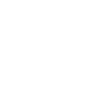

In [15]:
train_df.iloc[1000]['geometry']

In [16]:
## Filtering column "mail_type"
train_x = np.asarray(train_df[['geometry']].area)
train_x = train_x.reshape(-1, 1)
train_y = train_df['change_type'].apply(lambda x: change_type_map[x])

test_x = np.asarray(test_df[['geometry']].area)
test_x = test_x.reshape(-1, 1)

print (train_x.shape, train_y.shape, test_x.shape)

C:\Users\pedro\AppData\Local\Temp\ipykernel_18684\2230164977.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_x = np.asarray(train_df[['geometry']].area)


(296146, 1) (296146,) (120526, 1)


C:\Users\pedro\AppData\Local\Temp\ipykernel_18684\2230164977.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  test_x = np.asarray(test_df[['geometry']].area)
